# Heavy-Tailed SGD Geometry Analyzer

## Theory
Critical point fluctuations exhibit power-law tails (α-stable Lévy distributions). SGD gradient noise shows similar heavy-tailed statistics. This notebook:
1. Tracks gradient norm distributions across training regimes
2. Fits α-stable distributions (generalized CLT framework)
3. Correlates tail exponent α(t) with generalization gap
4. Tests hypothesis: α < 2 during phase transitions, → 2 at convergence

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
import seaborn as sns
from collections import defaultdict

sns.set_style('whitegrid')
torch.manual_seed(42)
np.random.seed(42)

In [2]:
class ModularArithmeticDataset:
    """Modular addition dataset for grokking experiments."""
    def __init__(self, p=97, frac_train=0.5):
        self.p = p
        # All possible pairs (a, b) -> (a + b) mod p
        inputs = []
        labels = []
        for a in range(p):
            for b in range(p):
                inputs.append([a, b])
                labels.append((a + b) % p)
        
        inputs = np.array(inputs)
        labels = np.array(labels)
        
        # Random train/test split
        n_samples = len(inputs)
        indices = np.random.permutation(n_samples)
        split_idx = int(frac_train * n_samples)
        
        self.train_inputs = torch.tensor(inputs[indices[:split_idx]], dtype=torch.long)
        self.train_labels = torch.tensor(labels[indices[:split_idx]], dtype=torch.long)
        self.test_inputs = torch.tensor(inputs[indices[split_idx:]], dtype=torch.long)
        self.test_labels = torch.tensor(labels[indices[split_idx:]], dtype=torch.long)

class ModularTransformer(nn.Module):
    """Simple transformer for modular arithmetic."""
    def __init__(self, p=97, d_model=128, nhead=4, num_layers=2):
        super().__init__()
        self.p = p
        self.embedding = nn.Embedding(p, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=512, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        self.fc = nn.Linear(d_model, p)
    
    def forward(self, x):
        # x: (batch, 2) containing [a, b]
        embedded = self.embedding(x)  # (batch, 2, d_model)
        transformed = self.transformer(embedded)  # (batch, 2, d_model)
        pooled = transformed.mean(dim=1)  # (batch, d_model)
        return self.fc(pooled)  # (batch, p)

In [3]:
def estimate_alpha_stable_params(gradients):
    """Estimate α-stable distribution parameters using McCulloch's quantile method.
    Returns (alpha, location, scale).
    """
    gradients = np.array(gradients)
    
    # Quantiles for McCulloch method
    q5 = np.percentile(gradients, 5)
    q25 = np.percentile(gradients, 25)
    q50 = np.percentile(gradients, 50)
    q75 = np.percentile(gradients, 75)
    q95 = np.percentile(gradients, 95)
    
    # Approximate alpha from interquantile ratios
    iqr_outer = q95 - q5
    iqr_inner = q75 - q25
    
    if iqr_outer == 0:
        return 2.0, q50, np.std(gradients)  # Gaussian fallback
    
    ratio = iqr_inner / iqr_outer
    
    # Empirical mapping: ratio → alpha
    # For α=2 (Gaussian): ratio ≈ 0.412
    # For α=1 (Cauchy): ratio ≈ 0.655
    alpha = 2.0 - 1.5 * (ratio - 0.412)
    alpha = np.clip(alpha, 0.5, 2.0)  # Valid range
    
    location = q50
    scale = iqr_inner / 1.349  # Scale from IQR
    
    return alpha, location, scale

def compute_kurtosis(gradients):
    """Compute excess kurtosis (0 for Gaussian, >0 for heavy tails)."""
    return stats.kurtosis(gradients)

class GradientStatisticsTracker:
    """Tracks gradient statistics during training."""
    def __init__(self, model):
        self.model = model
        self.history = defaultdict(list)
    
    def collect_gradients(self):
        """Flatten all gradients into single vector."""
        grads = []
        for param in self.model.parameters():
            if param.grad is not None:
                grads.append(param.grad.view(-1).detach().cpu().numpy())
        return np.concatenate(grads) if grads else np.array([])
    
    def update(self, epoch, train_loss, test_loss, train_acc, test_acc):
        """Record statistics for current epoch."""
        grads = self.collect_gradients()
        
        if len(grads) > 0:
            # Gradient statistics
            self.history['grad_norm'].append(np.linalg.norm(grads))
            self.history['grad_mean'].append(np.mean(grads))
            self.history['grad_std'].append(np.std(grads))
            
            # Heavy-tail statistics
            alpha, loc, scale = estimate_alpha_stable_params(grads)
            self.history['alpha'].append(alpha)
            self.history['kurtosis'].append(compute_kurtosis(grads))
            
            # Store sample of gradients for distribution analysis
            if epoch % 100 == 0:
                self.history[f'grad_dist_{epoch}'] = grads[:10000]  # Sample
        
        # Training metrics
        self.history['train_loss'].append(train_loss)
        self.history['test_loss'].append(test_loss)
        self.history['train_acc'].append(train_acc)
        self.history['test_acc'].append(test_acc)
        self.history['gen_gap'].append(test_loss - train_loss)

In [4]:
def train_with_statistics(model, train_loader, test_loader, epochs=5000, lr=1e-3):
    """Train model while tracking gradient statistics."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    tracker = GradientStatisticsTracker(model)
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        train_loss /= len(train_loader)
        train_acc = train_correct / train_total
        
        # Testing
        model.eval()
        test_loss = 0
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()
        
        test_loss /= len(test_loader)
        test_acc = test_correct / test_total
        
        # Update statistics (do one more forward pass to get fresh gradients)
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            break  # Just one batch for gradient statistics
        
        tracker.update(epoch, train_loss, test_loss, train_acc, test_acc)
        
        if epoch % 500 == 0:
            print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Test Loss={test_loss:.4f}, "
                  f"Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}, α={tracker.history['alpha'][-1]:.3f}")
    
    return tracker

In [5]:
# Run experiment
print("Generating modular arithmetic dataset...")
dataset = ModularArithmeticDataset(p=97, frac_train=0.5)

train_dataset = TensorDataset(dataset.train_inputs, dataset.train_labels)
test_dataset = TensorDataset(dataset.test_inputs, dataset.test_labels)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

print("\nTraining model...")
model = ModularTransformer(p=97, d_model=128, nhead=4, num_layers=2)
tracker = train_with_statistics(model, train_loader, test_loader, epochs=2000, lr=1e-3)

Generating modular arithmetic dataset...
Train samples: 4704, Test samples: 4705

Training model...
Epoch 0: Train Loss=4.6983, Test Loss=4.7267, Train Acc=0.0102, Test Acc=0.0057, α=2.000
Epoch 500: Train Loss=0.0038, Test Loss=0.0222, Train Acc=0.9998, Test Acc=0.9974, α=2.000
Epoch 1000: Train Loss=0.0005, Test Loss=0.0001, Train Acc=1.0000, Test Acc=1.0000, α=2.000
Epoch 1500: Train Loss=0.0007, Test Loss=0.0000, Train Acc=1.0000, Test Acc=1.0000, α=2.000


KeyboardInterrupt: 

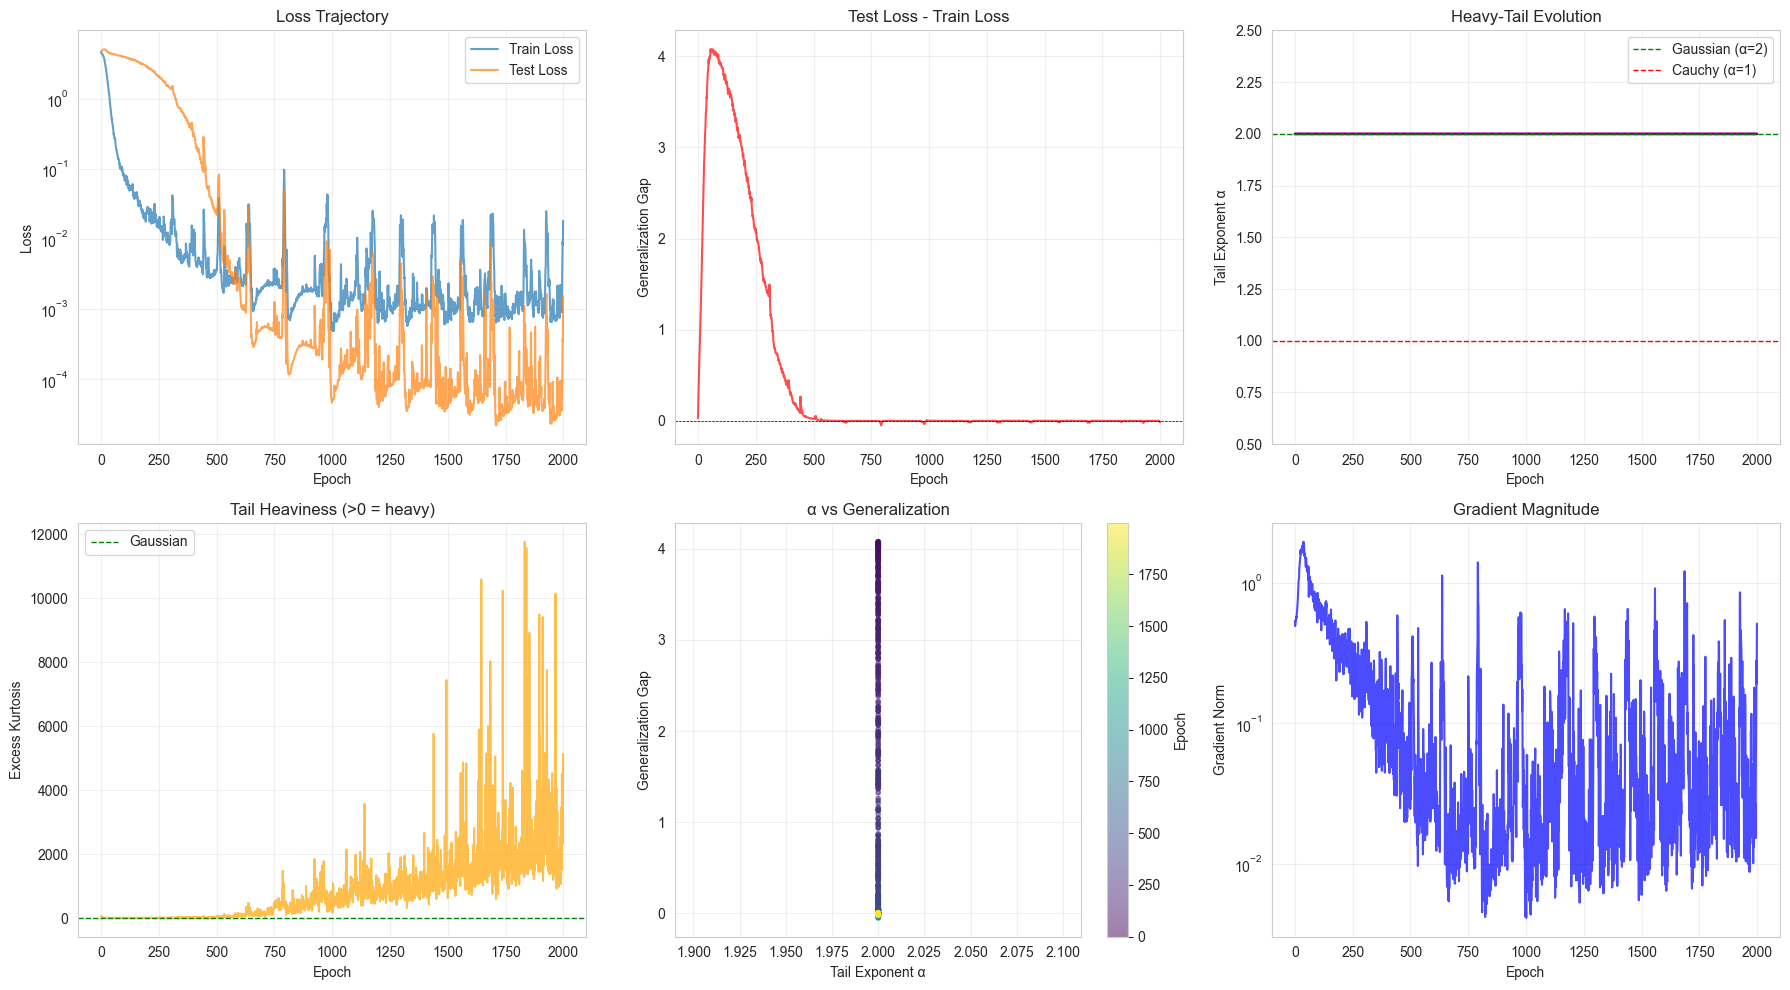


=== KEY FINDINGS ===
Initial α: 2.000
Final α: 2.000
Min α: 2.000 at epoch 0

Correlation (α, gen_gap): nan


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

epochs = np.arange(len(tracker.history['train_loss']))

# 1. Training dynamics
ax = axes[0, 0]
ax.plot(epochs, tracker.history['train_loss'], label='Train Loss', alpha=0.7)
ax.plot(epochs, tracker.history['test_loss'], label='Test Loss', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_yscale('log')
ax.legend()
ax.set_title('Loss Trajectory')
ax.grid(True, alpha=0.3)

# 2. Generalization gap
ax = axes[0, 1]
ax.plot(epochs, tracker.history['gen_gap'], color='red', alpha=0.7)
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Generalization Gap')
ax.set_title('Test Loss - Train Loss')
ax.grid(True, alpha=0.3)

# 3. Alpha evolution (KEY RESULT)
ax = axes[0, 2]
ax.plot(epochs, tracker.history['alpha'], color='purple', linewidth=2)
ax.axhline(2.0, color='green', linestyle='--', label='Gaussian (α=2)', linewidth=1)
ax.axhline(1.0, color='red', linestyle='--', label='Cauchy (α=1)', linewidth=1)
ax.set_xlabel('Epoch')
ax.set_ylabel('Tail Exponent α')
ax.set_title('Heavy-Tail Evolution')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 2.5])

# 4. Kurtosis evolution
ax = axes[1, 0]
ax.plot(epochs, tracker.history['kurtosis'], color='orange', alpha=0.7)
ax.axhline(0, color='green', linestyle='--', label='Gaussian', linewidth=1)
ax.set_xlabel('Epoch')
ax.set_ylabel('Excess Kurtosis')
ax.set_title('Tail Heaviness (>0 = heavy)')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Alpha vs Generalization Gap (correlation)
ax = axes[1, 1]
scatter = ax.scatter(tracker.history['alpha'], tracker.history['gen_gap'], 
                     c=epochs, cmap='viridis', alpha=0.5, s=10)
ax.set_xlabel('Tail Exponent α')
ax.set_ylabel('Generalization Gap')
ax.set_title('α vs Generalization')
plt.colorbar(scatter, ax=ax, label='Epoch')
ax.grid(True, alpha=0.3)

# 6. Gradient norm evolution
ax = axes[1, 2]
ax.plot(epochs, tracker.history['grad_norm'], color='blue', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Gradient Norm')
ax.set_yscale('log')
ax.set_title('Gradient Magnitude')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('heavy_tailed_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== KEY FINDINGS ===")
print(f"Initial α: {tracker.history['alpha'][0]:.3f}")
print(f"Final α: {tracker.history['alpha'][-1]:.3f}")
print(f"Min α: {min(tracker.history['alpha']):.3f} at epoch {np.argmin(tracker.history['alpha'])}")
print(f"\nCorrelation (α, gen_gap): {np.corrcoef(tracker.history['alpha'], tracker.history['gen_gap'])[0,1]:.3f}")

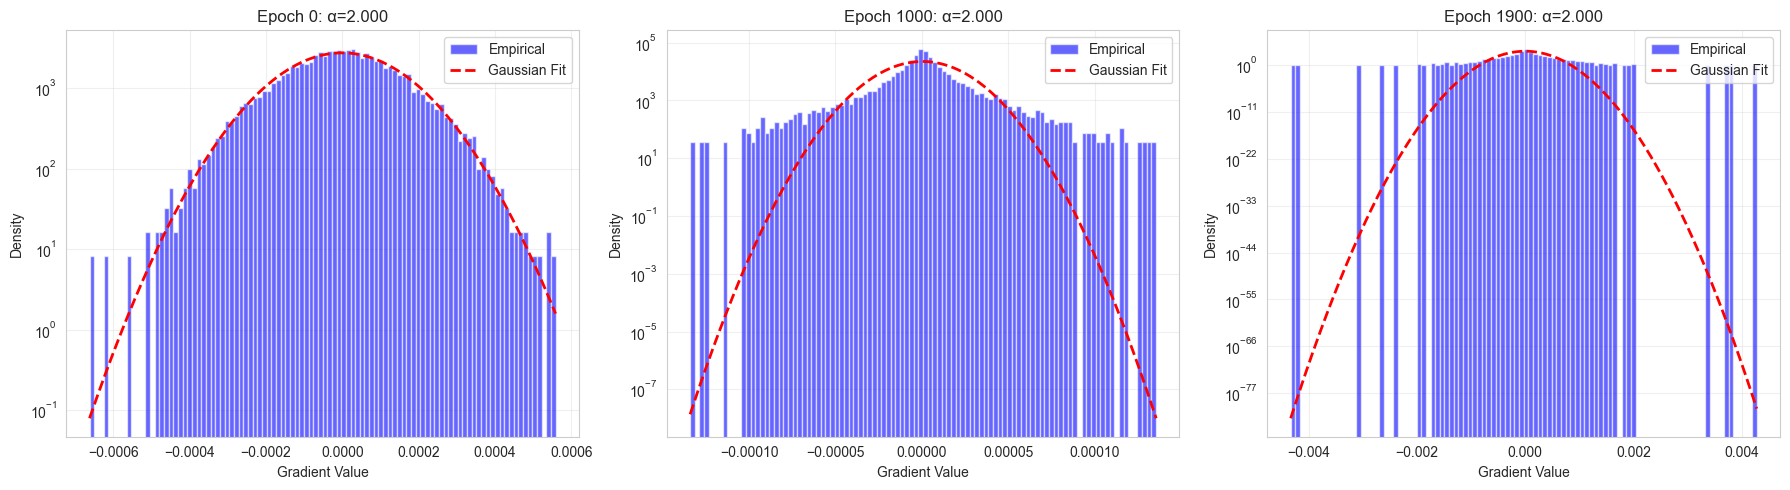

In [ ]:
# Distribution analysis at different phases
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_to_plot = [0, 1000, 1900]
for idx, epoch in enumerate(epochs_to_plot):
    key = f'grad_dist_{epoch}'
    if key in tracker.history:
        ax = axes[idx]
        grads = tracker.history[key]
        
        # Histogram
        ax.hist(grads, bins=100, density=True, alpha=0.6, color='blue', label='Empirical')
        
        # Fit Gaussian for comparison
        mu, sigma = np.mean(grads), np.std(grads)
        x = np.linspace(grads.min(), grads.max(), 1000)
        gaussian = stats.norm.pdf(x, mu, sigma)
        ax.plot(x, gaussian, 'r--', linewidth=2, label='Gaussian Fit')
        
        alpha_val = tracker.history['alpha'][epoch]
        ax.set_title(f'Epoch {epoch}: α={alpha_val:.3f}')
        ax.set_xlabel('Gradient Value')
        ax.set_ylabel('Density')
        ax.legend()
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gradient_distributions.png', dpi=300, bbox_inches='tight')
plt.show()